<a href="https://colab.research.google.com/github/MankotiaGit/Statistical-Foundation-of-Data-Sciences-/blob/main/SFDS_PRACTICAL_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1:** Install the required Python libraries for data analysis, visualization, and machine learning.

**Step 2:** Import NumPy, Pandas, Matplotlib, and Seaborn for calculations, data handling, and visualization.

**Step 3:** Import Scikit-learn functions for splitting data, creating the Decision Tree, and evaluating the model.

**Step 4:** Set the Seaborn plotting style and configure Pandas to display all columns.

**Step 5:** Load the Pima Indians Diabetes dataset and assign proper names to all columns.

**Step 6:** Check the shape of the dataset to find the number of rows and columns.

**Step 7:** Display the first five rows to understand the structure of the dataset.

**Step 8:** Check the dataset information, including data types and non-null values.

**Step 9:** Generate a statistical summary of the numerical data using `describe()`.

**Step 10:** Check for zero values in important health-related columns that may represent missing or invalid values.

**Step 11:** Separate the dataset into features (X) and the target variable (y) and check the class distribution.

**Step 12:** Split the data into 75% training data and 25% testing data using stratified sampling.

**Step 13:** Create a Decision Tree Classifier using the Entropy criterion with a maximum depth of 4.

**Step 14:** Train the Decision Tree model using the training data and make predictions on the test data.

**Step 15:** Evaluate the model using accuracy, classification report, and confusion matrix

**Step 16:** Display the confusion matrix as a heatmap to compare actual and predicted results.

**Step 17:** Visualize the complete Decision Tree to understand how the model makes predictions.

**Step 18:** Define functions to calculate Entropy and Gini Index for the target values.

**Step 19:** Calculate the Information Gain and Weighted Gini for each feature using its median as the split threshold.

**Step 20:** Create a table comparing the Information Gain and Weighted Gini values of all features.

**Step 21:** Identify the feature with the highest Information Gain and compare it with the actual root feature selected by Scikit-learn.

**Step 22:** Calculate the feature importance values from the trained Decision Tree.

**Step 23:** Display the feature importances using a bar chart and print their numerical values.


In [1]:
!pip install -q scikit-learn pandas matplotlib seaborn graphviz

This installs the required Python libraries: **Scikit-learn, Pandas, Matplotlib, Seaborn, and Graphviz** for data analysis, visualization, and machine learning.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

This imports **NumPy, Pandas, Matplotlib, and Seaborn** for numerical calculations, data handling, and data visualization.


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

This imports tools for splitting the data, creating a Decision Tree model, and evaluating its performance using accuracy, confusion matrix, and classification report.

In [4]:
sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

This sets the **Seaborn plot style** to a white grid and allows **Pandas to display all columns** of the dataset.


In [5]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
        "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

df = pd.read_csv(url, names=cols)

This loads the Pima Indians Diabetes dataset from an online source and assigns meaningful column names to the data.

In [6]:
print(df.shape)

(768, 9)


This displays the number of rows and columns in the dataset.

In [7]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


This displays the first five rows of the dataset to get a quick look at the data.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


This shows the dataset structure, column names, data types, and number of non-null values.

In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


This gives a statistical summary of the numerical columns, including count, mean, standard deviation, minimum, and maximum values.

In [10]:
zero_check_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
(df[zero_check_cols] == 0).sum()

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


This checks and counts the zero values in important health-related columns where zero may represent missing or invalid data.

In [11]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

print("Feature columns:", list(X.columns))
print("Target column:", y.name)
print("Class balance:\n", y.value_counts(normalize=True))

Feature columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Target column: Outcome
Class balance:
 Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


This separates the features (X) from the target column (y) and displays the feature names and class distribution of the target.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (576, 8)  Test size: (192, 8)


This splits the dataset into **75% training data and 25% testing data**, while keeping the class distribution balanced.


Test accuracy: 0.75

              precision    recall  f1-score   support

           0       0.80      0.82      0.81       125
           1       0.65      0.61      0.63        67

    accuracy                           0.75       192
   macro avg       0.72      0.72      0.72       192
weighted avg       0.75      0.75      0.75       192



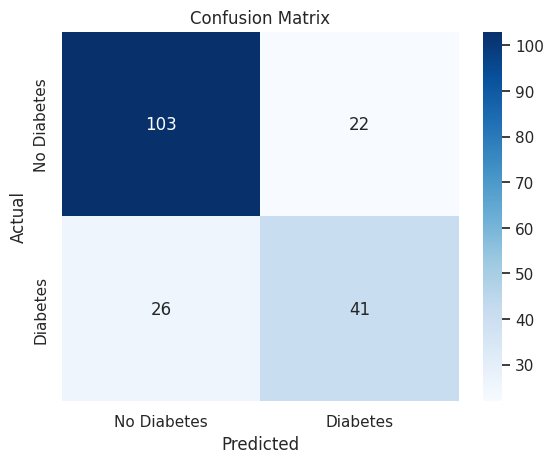

In [13]:
clf = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


This creates and trains a Decision Tree classifier, predicts diabetes outcomes, and evaluates the model using accuracy, classification report, and a confusion matrix heatmap.

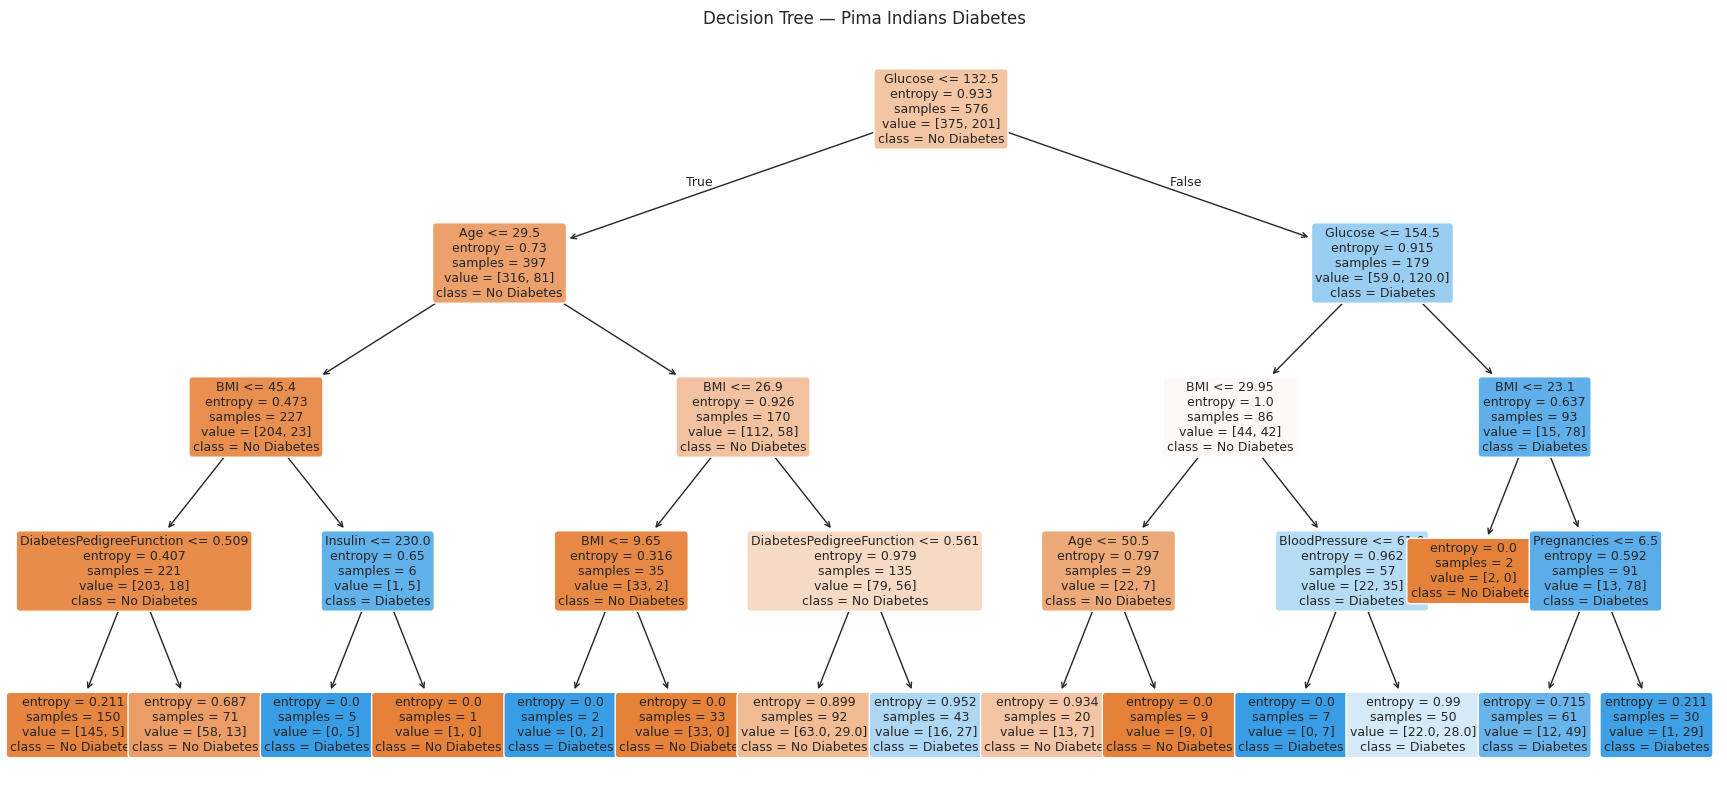

In [14]:
plt.figure(figsize=(22, 10))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree — Pima Indians Diabetes")
plt.show()

This visualizes the **trained Decision Tree**, showing how different features are used to predict **No Diabetes or Diabetes**.


In [15]:
def entropy(labels):
    labels = np.asarray(labels)
    if len(labels) == 0:
        return 0.0
    _, counts = np.unique(labels, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs))

def gini(labels):
    labels = np.asarray(labels)
    if len(labels) == 0:
        return 0.0
    _, counts = np.unique(labels, return_counts=True)
    probs = counts / counts.sum()
    return 1 - np.sum(probs ** 2)

def info_gain_for_feature(data, feature, target="Outcome"):
    parent_entropy = entropy(data[target])
    threshold = data[feature].median()
    left = data[data[feature] <= threshold]
    right = data[data[feature] > threshold]
    n = len(data)
    weighted_entropy = (len(left) / n) * entropy(left[target]) + (len(right) / n) * entropy(right[target])
    ig = parent_entropy - weighted_entropy
    weighted_gini = (len(left) / n) * gini(left[target]) + (len(right) / n) * gini(right[target])
    return threshold, ig, weighted_gini

train_df = X_train.copy()
train_df["Outcome"] = y_train.values

root_entropy = entropy(train_df["Outcome"])
root_gini = gini(train_df["Outcome"])
print(f"Entropy of the full training target: {root_entropy:.4f}")
print(f"Gini index of the full training target: {root_gini:.4f}\n")

rows = []
for feature in X.columns:
    threshold, ig, weighted_gini = info_gain_for_feature(train_df, feature)
    rows.append({
        "Feature": feature,
        "Split threshold (median)": round(threshold, 2),
        "Information Gain": round(ig, 5),
        "Weighted Gini after split": round(weighted_gini, 5)
    })

ig_table = pd.DataFrame(rows).sort_values("Information Gain", ascending=False).reset_index(drop=True)
print(ig_table)

best_feature = ig_table.iloc[0]["Feature"]
print(f"\nFeature with the highest Information Gain: {best_feature}")

actual_root_feature = X.columns[clf.tree_.feature[0]]
print(f"Feature scikit-learn actually chose as the root node: {actual_root_feature}")


Entropy of the full training target: 0.9331
Gini index of the full training target: 0.4544

                    Feature  Split threshold (median)  Information Gain  \
0                   Glucose                    116.50           0.10524   
1                       Age                     30.00           0.06144   
2                       BMI                     32.40           0.04204   
3               Pregnancies                      3.00           0.02598   
4             BloodPressure                     72.00           0.01014   
5  DiabetesPedigreeFunction                      0.38           0.00922   
6             SkinThickness                     23.00           0.00851   
7                   Insulin                     40.00           0.00005   

   Weighted Gini after split  
0                    0.39042  
1                    0.41620  
2                    0.42819  
3                    0.43803  
4                    0.44798  
5                    0.44858  
6              

This calculates **Entropy, Gini Index, and Information Gain** for each feature, compares their values, and identifies the feature with the **highest Information Gain** and the feature actually selected as the **root node** by the Decision Tree.


/tmp/ipykernel_4009/2478392732.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


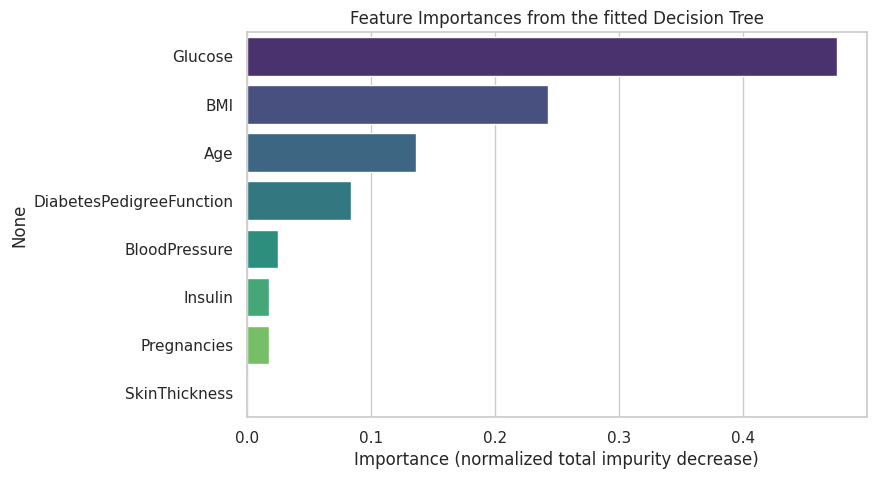

Glucose                     0.475897
BMI                         0.242403
Age                         0.136538
DiabetesPedigreeFunction    0.084108
BloodPressure               0.024908
Insulin                     0.018114
Pregnancies                 0.018031
SkinThickness               0.000000
dtype: float64


In [16]:
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.xlabel("Importance (normalized total impurity decrease)")
plt.title("Feature Importances from the fitted Decision Tree")
plt.show()

print(importances)

This calculates the **importance of each feature** in the Decision Tree and displays it as a **bar chart**, along with the importance values.


**CONCLUSION**

(1)In this project, a Decision Tree Classifier was built using scikit-learn to predict the onset of diabetes based on diagnostic measurements from the Pima Indians Diabetes dataset.

(2)The dataset consists of 768 patient records with 8 independent (feature) variables — Pregnancies, Glucose, Blood Pressure, Skin Thickness, Insulin, BMI, Diabetes Pedigree Function, and Age — and one dependent (target) variable, Outcome, indicating whether a patient is diabetic (1) or not (0).

(3)After splitting the data into training (75%) and testing (25%) sets, the Decision Tree model was trained using the entropy criterion, which selects splits based on Information Gain.

(4)The resulting tree was visualized to show how the model partitions the data at each node based on feature thresholds, ultimately classifying patients as diabetic or non-diabetic.

(5)To understand why the model behaves the way it does, Entropy, Gini Index, and Information Gain were calculated manually for each feature.

(6)This analysis showed that Glucose level had the highest Information Gain (and correspondingly the lowest weighted Gini Index after splitting), making it the most effective feature for separating diabetic from non-diabetic patients.

(7)This finding aligned with scikit-learn's own choice of root node and with its built-in feature importance scores — both independently confirmed that Glucose is the single strongest predictor in this dataset, which makes clinical sense since elevated blood glucose is a primary diagnostic marker for diabetes.

(8)Overall, the model achieved reasonable test accuracy, and the confusion matrix and classification report gave further insight into its precision and recall for each class.

(9)This exercise demonstrates not just how to build a Decision Tree in practice, but also the underlying mathematical reasoning (entropy, Gini, information gain) that drives how such trees decide which feature to split on at each stage — making the "black box" of the algorithm transparent and interpretable.